# Sentiment Exploration — Try & Error

Interactive notebook for inspecting Alpha Vantage sentiment data at every stage:
raw API → aggregation → on-disk files → processed → features.

Change `TICKER` and `FETCH_DATE` in Cell 1 and re-run any cell independently.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path('..').resolve()))   # repo root

import json
from datetime import date, datetime
from pprint import pprint

import pandas as pd
from dotenv import load_dotenv
import os

load_dotenv('../.env')

True

In [2]:
# ── Cell 1: Config — edit these ──────────────────────────────────────────────
TICKER     = "NVDA"          # ticker to test
FETCH_DATE = "2026-04-25"    # YYYY-MM-DD — date to fetch sentiment for

# ── Setup ────────────────────────────────────────────────────────────────────
AV_KEY = os.environ.get('ALPHA_VANTAGE_API_KEY', '')
if not AV_KEY:
    print('WARNING: ALPHA_VANTAGE_API_KEY not found in .env')
else:
    print(f'API key loaded ({len(AV_KEY)} chars)')

FETCH_DATE_OBJ = date.fromisoformat(FETCH_DATE)
RAW_SENT_DIR   = Path('../data/raw/sentiment')
PROC_DIR       = Path('../data/processed')
FEAT_DIR       = Path('../data/features')
print(f'Target: {TICKER} on {FETCH_DATE}')

API key loaded (16 chars)
Target: NVDA on 2026-04-25


## 1. Raw API response — what does Alpha Vantage actually return?

In [3]:
from src.ingestion.rate_limiter import RateLimiter
from src.ingestion.clients.alphavantage import AlphaVantageClient

# No throttling in notebook — we call manually
fast_limiter = RateLimiter(calls_per_minute=999)
client = AlphaVantageClient(api_key=AV_KEY, rate_limiter=fast_limiter)

raw = client._fetch_raw(TICKER, FETCH_DATE_OBJ)

n_articles = len(raw.get('feed') or [])
print(f'Total articles in feed: {n_articles}')
print(f'Top-level keys: {list(raw.keys())}')

if n_articles:
    print(f'\nFirst article keys: {list(raw["feed"][0].keys())}')
    ts = raw['feed'][0].get('ticker_sentiment', [])
    print(f'ticker_sentiment entries in first article: {len(ts)}')
    match = [t for t in ts if t.get('ticker') == TICKER]
    print(f'\nEntry for {TICKER}:')
    pprint(match[0] if match else 'not found in first article')

Total articles in feed: 50
Top-level keys: ['items', 'sentiment_score_definition', 'relevance_score_definition', 'feed']

First article keys: ['title', 'url', 'time_published', 'authors', 'summary', 'banner_image', 'source', 'category_within_source', 'source_domain', 'topics', 'overall_sentiment_score', 'overall_sentiment_label', 'ticker_sentiment']
ticker_sentiment entries in first article: 3

Entry for NVDA:
{'relevance_score': '0.881521',
 'ticker': 'NVDA',
 'ticker_sentiment_label': 'Somewhat-Bullish',
 'ticker_sentiment_score': '0.277831'}


## 2. Full feed — articles relevant to this ticker

In [4]:
MIN_RELEVANCE = 0.1

rows = []
for article in (raw.get('feed') or []):
    for ts in (article.get('ticker_sentiment') or []):
        if ts.get('ticker') != TICKER:
            continue
        try:
            relevance = float(ts['relevance_score'])
        except (KeyError, ValueError):
            relevance = 0.0
        rows.append({
            'title':              article.get('title', '')[:60],
            'time_published':     article.get('time_published', ''),
            'relevance_score':    relevance,
            'sentiment_score':    ts.get('ticker_sentiment_score'),
            'sentiment_label':    ts.get('ticker_sentiment_label'),
            'above_threshold':    relevance >= MIN_RELEVANCE,
        })

feed_df = pd.DataFrame(rows)
if feed_df.empty:
    print(f'No articles found for {TICKER}')
else:
    print(f'{len(feed_df)} articles — {feed_df["above_threshold"].sum()} above relevance threshold ({MIN_RELEVANCE})')
    display(feed_df.sort_values('relevance_score', ascending=False))

50 articles — 50 above relevance threshold (0.1)


,title,time_published,relevance_score,sentiment_score,sentiment_label,above_threshold
48,Nvidia Breakout Sends Chip Giant to First Reco...,20260424T200800,1.000000,0.445380,Bullish,True
40,Direxion Daily NVDA Bull 2X Shares declares qu...,20260424T233844,1.000000,0.190631,Somewhat-Bullish,True
5,"Nvidia, Snowflake, CrowdStrike, Best Buy, Inte...",20260425T183706,1.000000,0.009315,Neutral,True
7,"Nvidia, Palantir, Super Micro Computer: High-f...",20260425T173000,1.000000,-0.215983,Somewhat-Bearish,True
23,Elm3 Financial Group LLC Lowers Holdings in NV...,20260425T075614,1.000000,0.210034,Somewhat-Bullish,True
12,"Nvidia leads market cap race as Microsoft, App...",20260425T133809,1.000000,0.452107,Bullish,True
14,Nvidia poised to be largest company by market ...,20260425T130806,1.000000,0.478481,Bullish,True
0,"Is Himax a ‘stealth’ supplier to Nvidia, Apple...",20260425T230906,0.881521,0.277831,Somewhat-Bullish,True
42,CGDV ETF Price: CGDV Holds $46.17 as $31.5B AU...,20260424T213936,0.867470,0.432331,Bullish,True
8,SPDR S&P 500 ETF Trust Sees Gains and Strong I...,20260425T161243,0.867057,0.725287,Bullish,True


## 3. Aggregation — what does the pipeline produce from this feed?

In [5]:
record = client._aggregate(TICKER, FETCH_DATE_OBJ, raw)

print(f'SentimentRecord for {TICKER} on {FETCH_DATE}:')
print(f'  bullish_percent:   {record.bullish_percent}')
print(f'  bearish_percent:   {record.bearish_percent}')
print(f'  company_news_score:{record.company_news_score}')
print(f'  article_count:     {record.article_count}')
print()

all_null = all(v is None for v in [
    record.bullish_percent, record.bearish_percent,
    record.company_news_score, record.article_count
])
status = 'NULL (no relevant articles)' if all_null else 'OK'
print(f'Pipeline status: {status}')

SentimentRecord for NVDA on 2026-04-25:
  bullish_percent:   0.82
  bearish_percent:   0.02
  company_news_score:0.2916
  article_count:     50.0

Pipeline status: OK


## 4. What's already on disk — inventory of all raw sentiment files

In [6]:
inventory = []
for ticker_dir in sorted(RAW_SENT_DIR.iterdir()):
    if not ticker_dir.is_dir():
        continue
    for f in sorted(ticker_dir.glob('*.csv')):
        try:
            df = pd.read_csv(f)
            has_data = not df.empty and df['company_news_score'].notna().any()
            status = 'data' if has_data else 'null'
        except Exception as e:
            status = f'error: {e}'
        inventory.append({'ticker': ticker_dir.name, 'date': f.stem, 'status': status})

inv_df = pd.DataFrame(inventory)
if inv_df.empty:
    print('No sentiment files on disk yet')
else:
    summary = inv_df.groupby('status').size().rename('count')
    print('On-disk sentiment files:')
    display(summary)
    print(f'\nTickers with at least one data file: {inv_df[inv_df["status"]=="data"]["ticker"].nunique()}')
    display(inv_df)

On-disk sentiment files:


status
data     25
null    116
Name: count, dtype: int64


Tickers with at least one data file: 20


,ticker,date,status
0,AAL,2026-04-23,null
1,AAL,2026-04-24,null
2,AAPL,2026-04-23,null
3,AGPU,2026-04-23,null
4,AIXI,2026-04-23,data
...,...,...,...
136,TZA,2026-04-25,null
137,UVIX,2026-04-24,null
138,WIMI,2026-04-24,null
139,WU,2026-04-24,data


## 5. Coverage heatmap — which tickers have data on which dates?

/var/folders/cj/812gpkjs49d6z5vj1j3r4njr0000gn/T/ipykernel_58010/1584874096.py:9: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  num_pivot = pivot.applymap(lambda s: status_to_num.get(s if isinstance(s, str) and s in status_to_num else 'missing', -1))


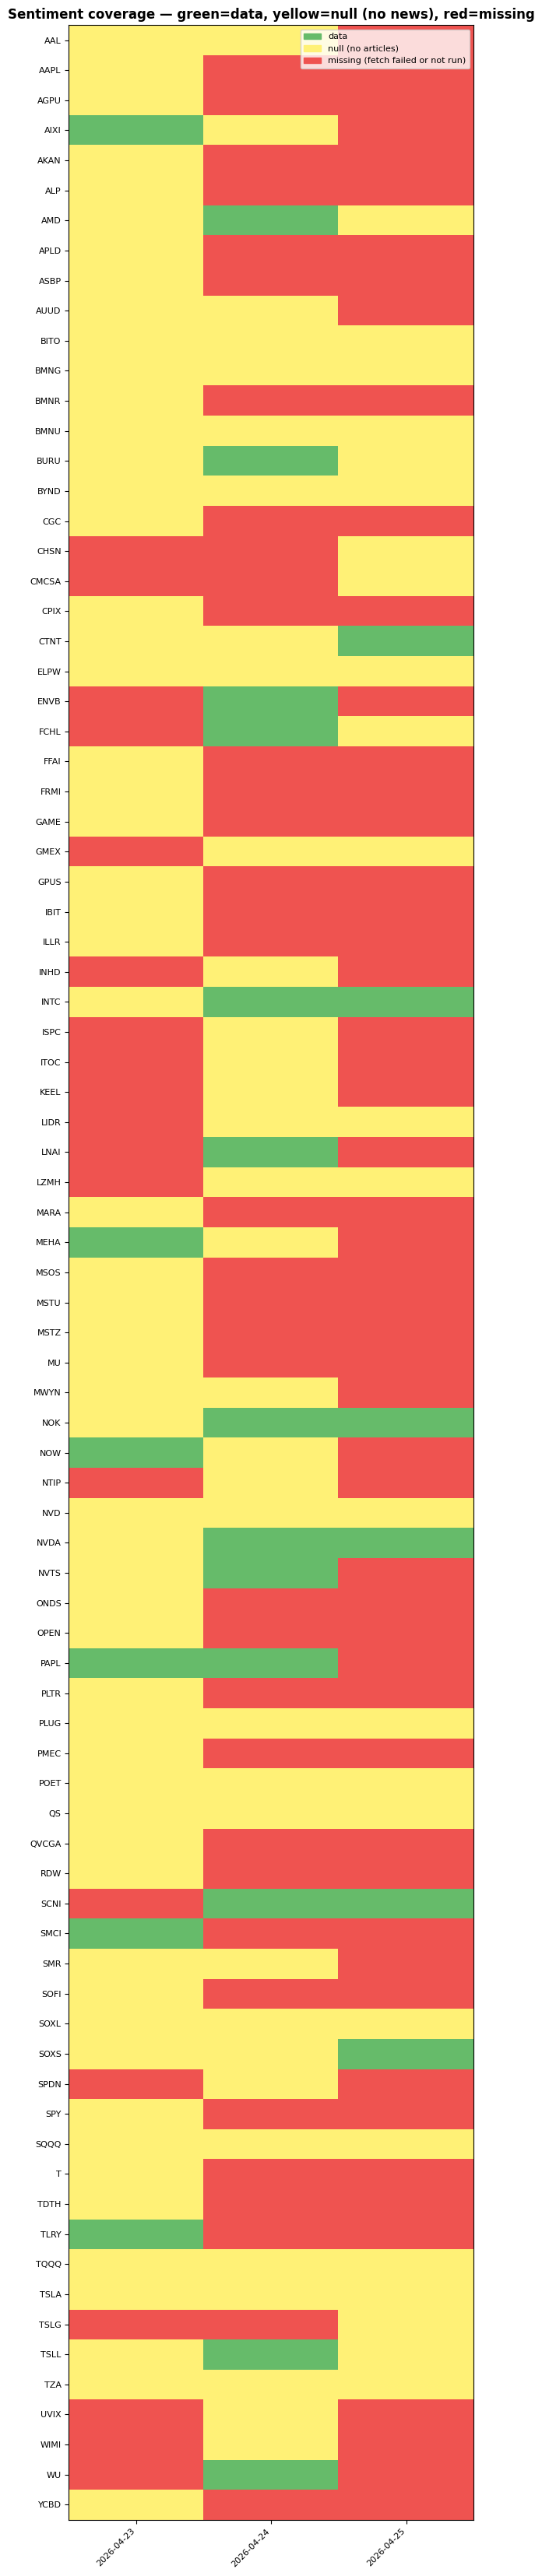

In [7]:
import matplotlib.pyplot as plt
import numpy as np

if inv_df.empty:
    print('No sentiment files on disk — run make nightly first')
else:
    pivot = inv_df.pivot(index='ticker', columns='date', values='status').fillna('missing')
    status_to_num = {'data': 1, 'null': 0, 'missing': -1}
    num_pivot = pivot.applymap(lambda s: status_to_num.get(s if isinstance(s, str) and s in status_to_num else 'missing', -1))

    fig, ax = plt.subplots(figsize=(max(6, len(pivot.columns) * 1.2), max(4, len(pivot) * 0.4)))
    cmap = plt.cm.colors.ListedColormap(['#EF5350', '#FFF176', '#66BB6A'])  # red/yellow/green
    im = ax.imshow(num_pivot.values, cmap=cmap, vmin=-1, vmax=1, aspect='auto')

    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels(pivot.columns, rotation=45, ha='right', fontsize=8)
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index, fontsize=8)
    ax.set_title('Sentiment coverage — green=data, yellow=null (no news), red=missing', fontweight='bold')

    from matplotlib.patches import Patch
    ax.legend(handles=[
        Patch(color='#66BB6A', label='data'),
        Patch(color='#FFF176', label='null (no articles)'),
        Patch(color='#EF5350', label='missing (fetch failed or not run)'),
    ], loc='upper right', fontsize=8)

    plt.tight_layout()
    plt.show()

## 6. Pipeline trace — does sentiment make it through to features?

In [8]:
SENTIMENT_COLS = ['bullish_percent', 'bearish_percent', 'company_news_score', 'article_count', 'sentiment_available']

def load_latest(directory: Path, ticker: str, label: str) -> pd.DataFrame | None:
    ticker_dir = directory / ticker
    if not ticker_dir.exists():
        print(f'  [{label}] no directory for {ticker}')
        return None
    files = sorted(ticker_dir.glob('*.csv'))
    if not files:
        print(f'  [{label}] no CSV files for {ticker}')
        return None
    df = pd.read_csv(files[-1])
    print(f'  [{label}] {files[-1].name} — {len(df)} rows, sentiment cols present: {[c for c in SENTIMENT_COLS if c in df.columns]}')
    return df

print(f'Pipeline trace for {TICKER}:\n')
proc_df = load_latest(PROC_DIR, TICKER, 'processed')
feat_df = load_latest(FEAT_DIR, TICKER, 'features')

for label, df in [('processed', proc_df), ('features', feat_df)]:
    if df is None:
        continue
    avail_col = 'sentiment_available'
    if avail_col in df.columns:
        n_available = df[avail_col].astype(str).str.lower().isin(['true', '1']).sum()
        print(f'\n  [{label}] sentiment_available=True on {n_available}/{len(df)} rows')
        if n_available:
            print(df[df[avail_col].astype(str).str.lower().isin(['true', '1'])][['date'] + [c for c in SENTIMENT_COLS if c in df.columns]].tail(5).to_string(index=False))

Pipeline trace for NVDA:

  [processed] 2026-04-25.csv — 501 rows, sentiment cols present: ['bullish_percent', 'bearish_percent', 'company_news_score', 'sentiment_available']
  [features] 2026-04-25.csv — 470 rows, sentiment cols present: ['bullish_percent', 'bearish_percent', 'company_news_score', 'sentiment_available']

  [processed] sentiment_available=True on 0/501 rows

  [features] sentiment_available=True on 0/470 rows


## 7. Live test — re-run this cell with any ticker/date

In [ ]:
# Change these and re-run:
TEST_TICKER = TICKER
TEST_DATE   = FETCH_DATE_OBJ

print(f'Testing sentiment pipeline for {TEST_TICKER} on {TEST_DATE}\n')
results = {}

# Stage 1: API fetch
try:
    raw_data = client._fetch_raw(TEST_TICKER, TEST_DATE)
    feed_len = len(raw_data.get('feed') or [])
    results['1. API fetch'] = f'OK — {feed_len} articles in feed'
except Exception as e:
    results['1. API fetch'] = f'FAIL — {e}'

# Stage 2: Aggregation
try:
    rec = client._aggregate(TEST_TICKER, TEST_DATE, raw_data)
    all_null = all(v is None for v in [rec.bullish_percent, rec.bearish_percent, rec.company_news_score, rec.article_count])
    results['2. Aggregation'] = f'null (no relevant articles)' if all_null else f'OK — score={rec.company_news_score:.3f}, articles={rec.article_count}'
except Exception as e:
    results['2. Aggregation'] = f'FAIL — {e}'

# Stage 3: On-disk raw file
raw_path = RAW_SENT_DIR / TEST_TICKER / f'{TEST_DATE}.csv'
if raw_path.exists():
    df_raw = pd.read_csv(raw_path)
    has_data = df_raw['company_news_score'].notna().any()
    results['3. Raw file'] = f'EXISTS — {"has data" if has_data else "all null"}'
else:
    results['3. Raw file'] = 'MISSING — nightly has not run for this date, or fetch failed'

# Stage 4: Processed file (any date)
proc_path = PROC_DIR / TEST_TICKER
results['4. Processed dir'] = 'EXISTS' if proc_path.exists() else 'MISSING — preprocessing not run for this ticker'

# Stage 5: Feature file (any date)
feat_path = FEAT_DIR / TEST_TICKER
results['5. Features dir'] = 'EXISTS' if feat_path.exists() else 'MISSING — feature pipeline not run for this ticker'

print('Stage results:')
for stage, result in results.items():
    icon = '✓' if result.startswith('OK') or result.startswith('EXISTS') else ('~' if 'null' in result.lower() or 'MISSING' in result else '✗')
    print(f'  {icon} {stage}: {result}')